In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# importing dataset from kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\lsauc\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


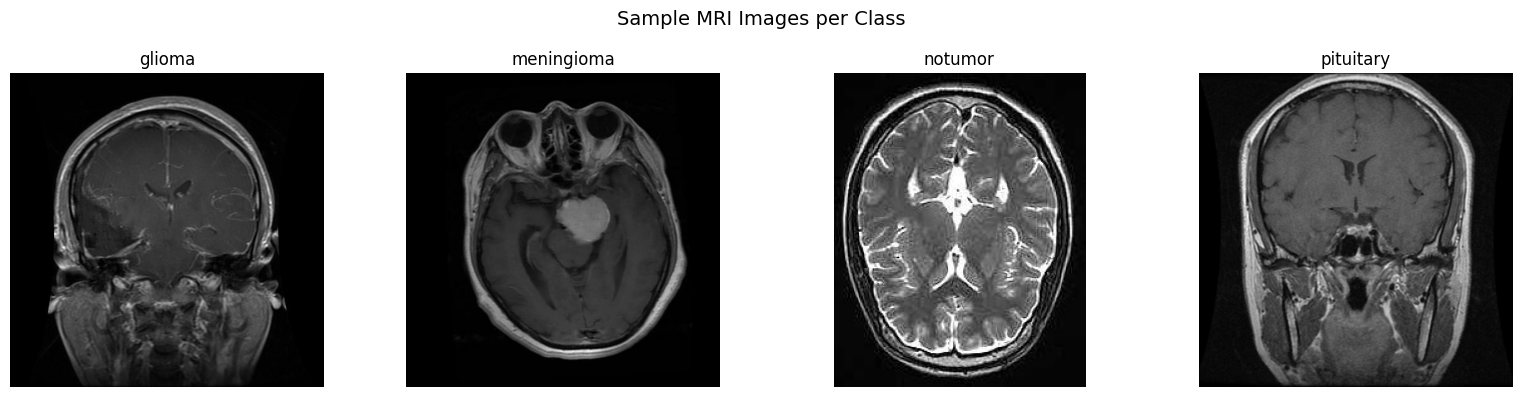

In [27]:
TRAIN_DIR = os.path.join(path, "Training")
TEST_DIR  = os.path.join(path, "Testing")

# Sort by common brain tumor types

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)

# Count images per class
for split_name, split_dir in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    print(f"\n{split_name}:")
    for cls in CLASS_NAMES:
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            print(f"  {cls}: {len(os.listdir(cls_path))} images")

# Show one sample image per class
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, sample))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample MRI Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

── Degradation Types ──
  Gaussian Noise       | param: std    | range: [0.02, 0.05, 0.1, 0.15, 0.2]
  Salt & Pepper        | param: amount | range: [0.01, 0.03, 0.05, 0.08, 0.1]
  Contrast Reduction   | param: factor | range: [0.8, 0.6, 0.4, 0.2, 0.1]
  Speckle Noise        | param: std    | range: [0.05, 0.1, 0.15, 0.2, 0.3]

Loading images at 64x64 resolution...
Training set: (5600, 64, 64, 3), Test set: (1600, 64, 64, 3)
Train: (4480, 64, 64, 3), Val: (1120, 64, 64, 3), Test: (1600, 64, 64, 3)


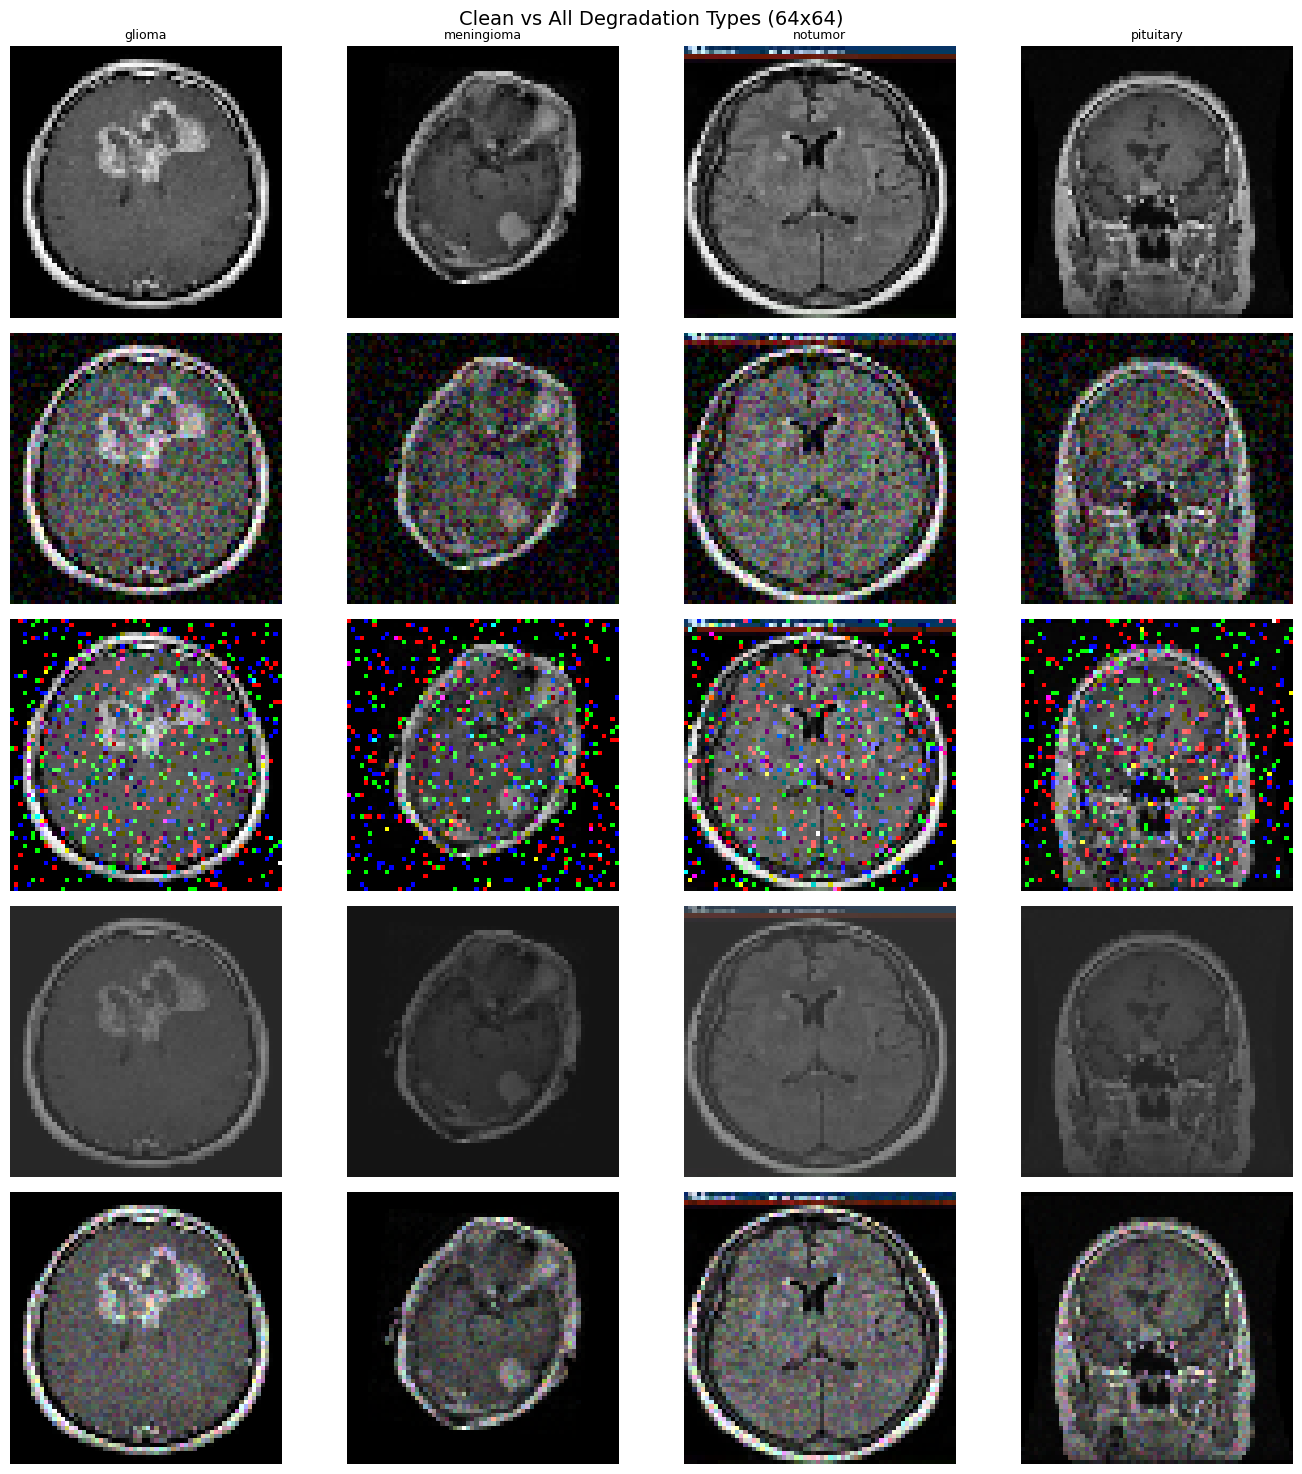

In [38]:
# ── Configuration ──
IMG_SIZE = 64          # Low resolution target
NUM_CLASSES = len(CLASS_NAMES)

# ── Degradation Functions ──
from scipy.ndimage import gaussian_filter

def add_gaussian_noise_deg(images, std=0.05):
    """Additive Gaussian noise."""
    noise = np.random.normal(0, std, images.shape)
    return np.clip(images + noise, 0.0, 1.0)

def add_salt_and_pepper(images, amount=0.05):
    """Salt-and-pepper (impulse) noise."""
    out = images.copy()
    num_salt = int(amount * images[0].size * len(images))
    coords = tuple(np.random.randint(0, d, num_salt) for d in [len(images)] + list(images.shape[1:]))
    out[coords] = 1.0
    num_pepper = int(amount * images[0].size * len(images))
    coords = tuple(np.random.randint(0, d, num_pepper) for d in [len(images)] + list(images.shape[1:]))
    out[coords] = 0.0
    return out

def reduce_contrast(images, factor=0.5):
    """Reduce contrast toward the mean."""
    mean = images.mean(axis=(1, 2, 3), keepdims=True)
    return np.clip(mean + factor * (images - mean), 0.0, 1.0)

def add_speckle_noise(images, std=0.05):
    """Multiplicative speckle noise (common in medical imaging)."""
    noise = np.random.normal(0, std, images.shape)
    return np.clip(images + images * noise, 0.0, 1.0)

DEGRADATIONS = {
    "Gaussian Noise":    (add_gaussian_noise_deg, "std",    [0.02, 0.05, 0.10, 0.15, 0.20]),
    "Salt & Pepper":     (add_salt_and_pepper,    "amount", [0.01, 0.03, 0.05, 0.08, 0.10]),
    "Contrast Reduction":(reduce_contrast,         "factor", [0.8,  0.6,  0.4,  0.2,  0.1]),
    "Speckle Noise":     (add_speckle_noise,      "std",    [0.05, 0.10, 0.15, 0.20, 0.30]),
}

# Print all degradation types and their parameter ranges
print("── Degradation Types ──")
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    print(f"  {deg_name:20s} | param: {param_name:6s} | range: {values}")

# ── Load Dataset ──
def load_dataset(data_dir, img_size):
    """Load all images from a directory into arrays."""
    images, labels = [], []
    for label_idx, cls in enumerate(CLASS_NAMES):
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = load_img(fpath, target_size=(img_size, img_size))
                images.append(img_to_array(img) / 255.0)
                labels.append(label_idx)
            except Exception:
                continue
    return np.array(images), np.array(labels)

print(f"\nLoading images at {IMG_SIZE}x{IMG_SIZE} resolution...")
X_train_full, y_train_full = load_dataset(TRAIN_DIR, IMG_SIZE)
X_test, y_test = load_dataset(TEST_DIR, IMG_SIZE)
print(f"Training set: {X_train_full.shape}, Test set: {X_test.shape}")

# Split training into train + validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Create noisy test set for robustness evaluation later
X_test_noisy = add_gaussian_noise_deg(X_test, std=0.10)

# ── Visualize clean vs ALL degradation types ──
# Pick one sample per class so all tumor types are shown
sample_indices = []
for cls_idx in range(NUM_CLASSES):
    idx = np.where(y_test == cls_idx)[0][0]
    sample_indices.append(idx)
n_samples = len(sample_indices)

n_rows = 1 + len(DEGRADATIONS)  # clean row + one row per degradation
fig, axes = plt.subplots(n_rows, n_samples, figsize=(14, 3 * n_rows))

# Row 0: Clean images (one per class)
for j, idx in enumerate(sample_indices):
    axes[0, j].imshow(X_test[idx])
    axes[0, j].set_title(CLASS_NAMES[y_test[idx]], fontsize=9)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=10, rotation=0, labelpad=70, va='center')

# Rows 1+: Each degradation type at a moderate intensity
for row, (deg_name, (deg_fn, param_name, values)) in enumerate(DEGRADATIONS.items(), start=1):
    mid_val = values[len(values) // 2]  # pick middle intensity
    X_deg = deg_fn(X_test[sample_indices], **{param_name: mid_val})
    for j in range(n_samples):
        axes[row, j].imshow(X_deg[j])
        axes[row, j].axis("off")
    axes[row, 0].set_ylabel(f"{deg_name}\n({param_name}={mid_val})",
                             fontsize=9, rotation=0, labelpad=80, va='center')

plt.suptitle(f"Clean vs All Degradation Types ({IMG_SIZE}x{IMG_SIZE})", fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
# ── Build CNN Model (Kaggle lab-cnn style, optimized) ──
def build_cnn(img_size, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_cnn(IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\lsauc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_76 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,409,188 (13.01 MB)

 Trainable params: 3,405,732 (12.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 295ms/step - accuracy: 0.7230 - loss: 0.7084 - val_accuracy: 0.5589 - val_loss: 1.2919 - learning_rate: 2.5000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 287ms/step - accuracy: 0.7373 - loss: 0.6575 - val_accuracy: 0.4482 - val_loss: 1.7354 - learning_rate: 2.5000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 280ms/step - accuracy: 0.7551 - loss: 0.6095 - val_accuracy: 0.4018 - val_loss: 2.1863 - learning_rate: 2.5000e-04
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.7674 - loss: 0.5905 - val_accuracy: 0.5152 - val_loss: 1.3669 - learning_rate: 2.5000e-04
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 301ms/step - accuracy: 0.7882 - loss: 0.5566 - val_accuracy: 0.2866 - val_loss: 3.2765 - learning_rate: 2.5000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 307ms/step - accuracy: 0.8129 - loss: 0.4947 - val_accuracy: 0.4821 - val_loss: 1.6346 - learning_rate: 1.2500e-04
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 29

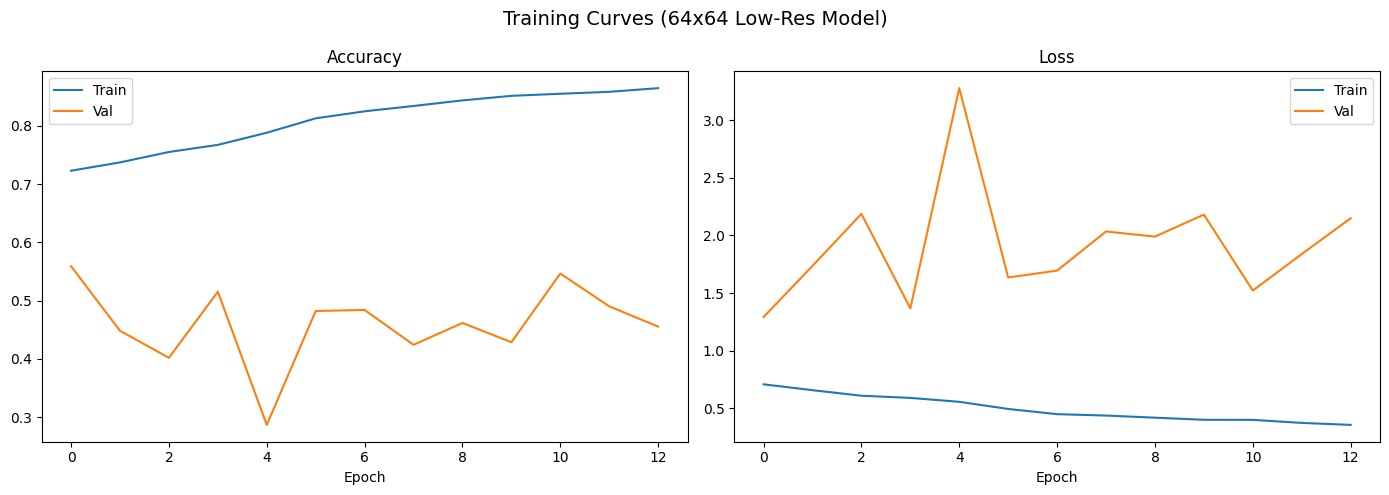

In [41]:
# ── Data Augmentation & Training ──
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
])

BATCH_SIZE = 32
#Not training past 10 epochs (?) increase threshold from 30
EPOCHS = 50

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).batch(BATCH_SIZE).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks = [
    keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy', mode='max'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor='val_loss', min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle(f"Training Curves ({IMG_SIZE}x{IMG_SIZE} Low-Res Model)", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# ── Evaluate on Clean Test Data ──
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (Clean, {IMG_SIZE}x{IMG_SIZE}): {test_acc:.4f}\n")
print("Classification Report (Clean Test Set):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ── Evaluate on Noisy Test Data ──
y_pred_noisy_probs = model.predict(X_test_noisy)
y_pred_noisy = np.argmax(y_pred_noisy_probs, axis=1)

noisy_acc = accuracy_score(y_test, y_pred_noisy)
print(f"\nTest Accuracy (Noisy, std=0.10): {noisy_acc:.4f}\n")
print("Classification Report (Noisy Test Set):")
print(classification_report(y_test, y_pred_noisy, target_names=CLASS_NAMES))

# Summary comparison
print("\n── Robustness Summary ──")
print(f"Clean accuracy:  {test_acc:.4f}")
print(f"Noisy accuracy:  {noisy_acc:.4f}")
print(f"Accuracy drop:   {test_acc - noisy_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
Test Accuracy (Clean, 64x64): 0.5506

Classification Report (Clean Test Set):
              precision    recall  f1-score   support

      glioma       0.91      0.13      0.22       400
  meningioma       0.53      0.12      0.20       400
     notumor       0.76      0.97      0.85       400
   pituitary       0.42      0.99      0.59       400

    accuracy                           0.55      1600
   macro avg       0.65      0.55      0.46      1600
weighted avg       0.65      0.55      0.46      1600

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step

Test Accuracy (Noisy, std=0.10): 0.2569

Classification Report (Noisy Test Set):
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.25      1.00      0.40       400
   pituitary       0.55      0.03      0.05       400

    accuracy                           0.26      1600

C:\Users\lsauc\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lsauc\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lsauc\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Gaussian Noise: [(0.02, '0.4981'), (0.05, '0.4131'), (0.1, '0.2562'), (0.15, '0.2500'), (0.2, '0.2500')]
Salt & Pepper: [(0.01, '0.3131'), (0.03, '0.2500'), (0.05, '0.2500'), (0.08, '0.2500'), (0.1, '0.2500')]
Contrast Reduction: [(0.8, '0.5088'), (0.6, '0.4288'), (0.4, '0.3137'), (0.2, '0.2500'), (0.1, '0.1556')]
Speckle Noise: [(0.05, '0.5375'), (0.1, '0.5144'), (0.15, '0.4938'), (0.2, '0.4650'), (0.3, '0.3200')]


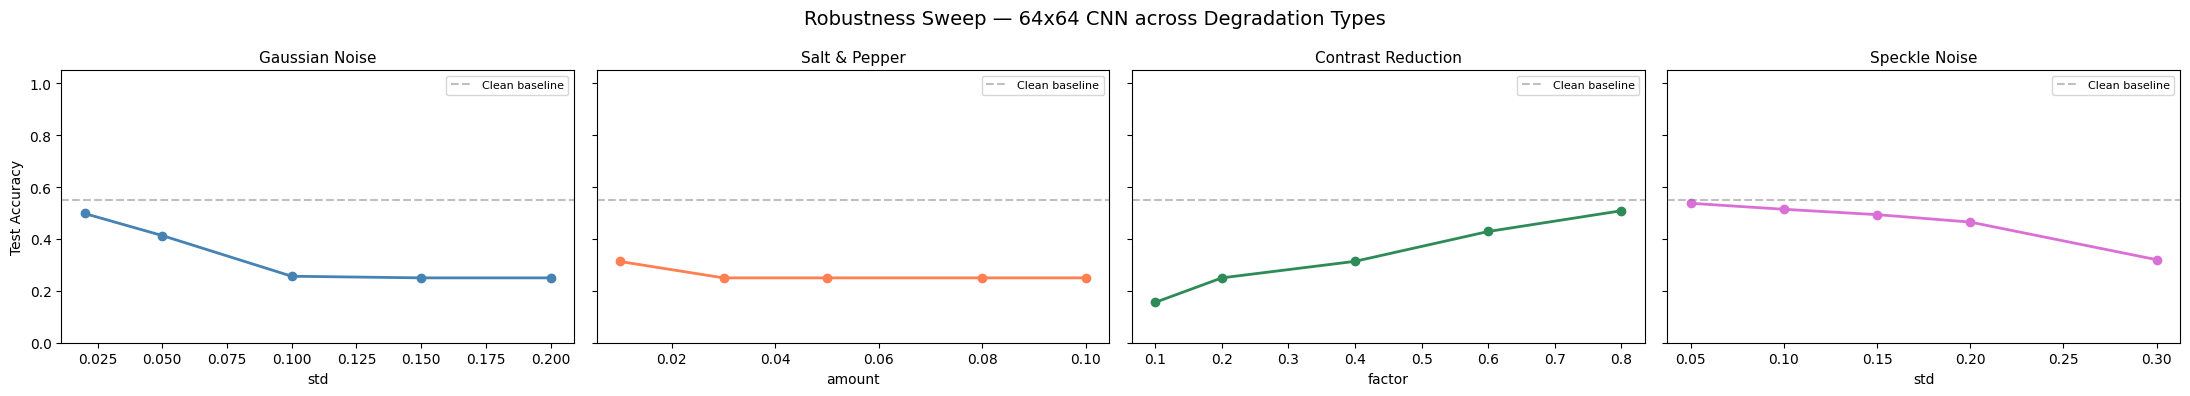

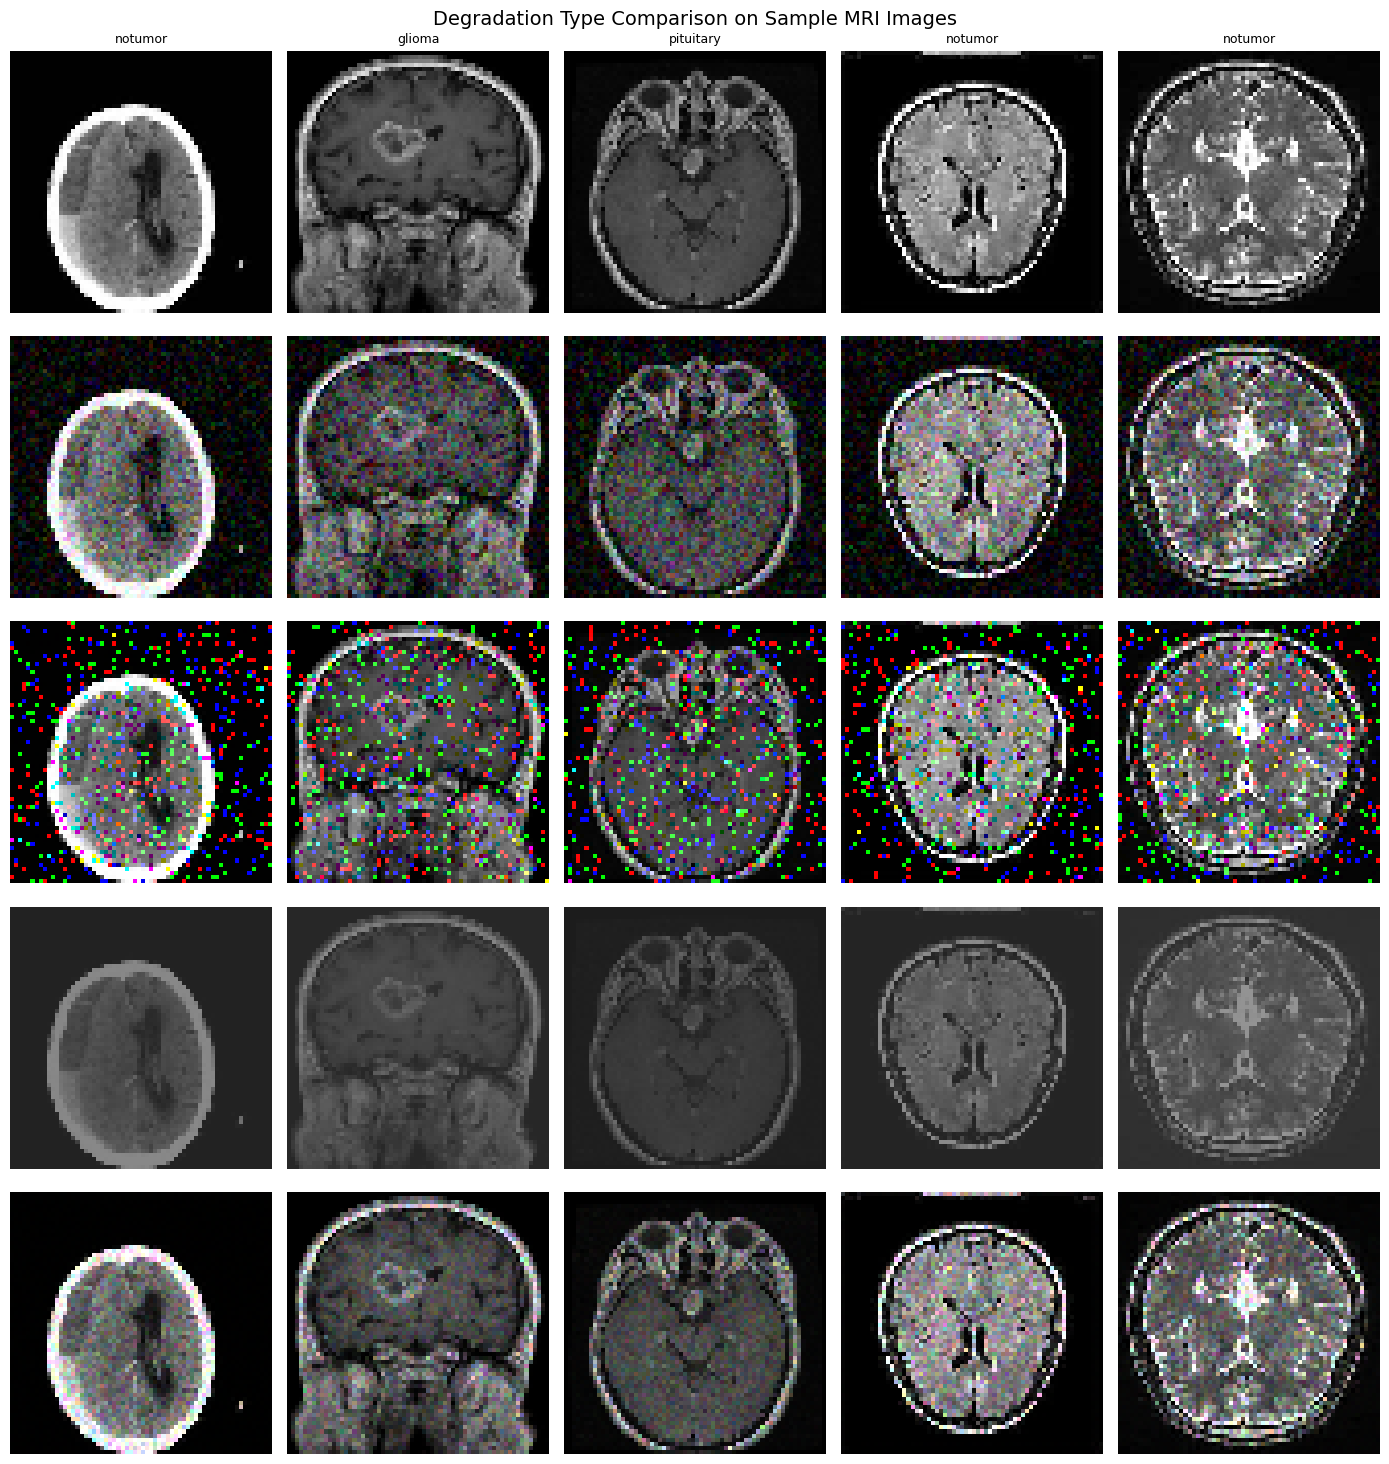

In [43]:
# ── Degradation Sweep: Evaluate clean-trained model across all noise types ──
colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

results = {}
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    results[deg_name] = (values, accs)
    print(f"{deg_name}: {list(zip(values, [f'{a:.4f}' for a in accs]))}")

# --- Plot accuracy vs degradation intensity ---
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(22, 4), sharey=True)
for ax, (deg_name, (vals, accs)), color in zip(axes, results.items(), colors):
    ax.plot(vals, accs, 'o-', color=color, linewidth=2)
    ax.axhline(y=test_acc, color='gray', linestyle='--', alpha=0.5, label='Clean baseline')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle(f'Robustness Sweep — {IMG_SIZE}x{IMG_SIZE} CNN across Degradation Types', fontsize=14)
plt.tight_layout()
plt.show()

# --- Visual comparison of all degradation types at a moderate level ---
fig, axes = plt.subplots(len(DEGRADATIONS) + 1, 5, figsize=(14, 3 * (len(DEGRADATIONS) + 1)))
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for j, idx in enumerate(sample_indices):
    axes[0, j].imshow(X_test[idx])
    axes[0, j].set_title(CLASS_NAMES[y_test[idx]], fontsize=9)
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=10, rotation=0, labelpad=60, va='center')

for row, (deg_name, (deg_fn, param_name, values)) in enumerate(DEGRADATIONS.items(), start=1):
    mid_val = values[len(values) // 2]
    X_deg_sample = deg_fn(X_test[sample_indices], **{param_name: mid_val})
    for j in range(5):
        axes[row, j].imshow(X_deg_sample[j])
        axes[row, j].axis("off")
    axes[row, 0].set_ylabel(f"{deg_name}\n({param_name}={mid_val})",
                             fontsize=9, rotation=0, labelpad=80, va='center')

plt.suptitle("Degradation Type Comparison on Sample MRI Images", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\lsauc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training noise-augmented (robust) model...
Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.4666 - loss: 1.5537  val_noisy_acc: 0.2500
140/140 ━━━━━━━━━━━━━━━━━━━━ 63s 341ms/step - accuracy: 0.5301 - loss: 1.3430 - val_accuracy: 0.2500 - val_loss: 3.2320 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.5894 - loss: 1.1056  val_noisy_acc: 0.1562
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 327ms/step - accuracy: 0.6067 - loss: 1.0221 - val_accuracy: 0.2536 - val_loss: 2.4517 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6437 - loss: 0.9153  val_noisy_acc: 0.4625
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 318ms/step - accuracy: 0.6574 - loss: 0.8820 - val_accuracy: 0.5786 - val_loss: 1.0849 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6992 - loss: 0.7696  val_noisy_acc: 0.4714
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 291ms/step - accuracy: 0.6940 - loss: 0.7836 - v

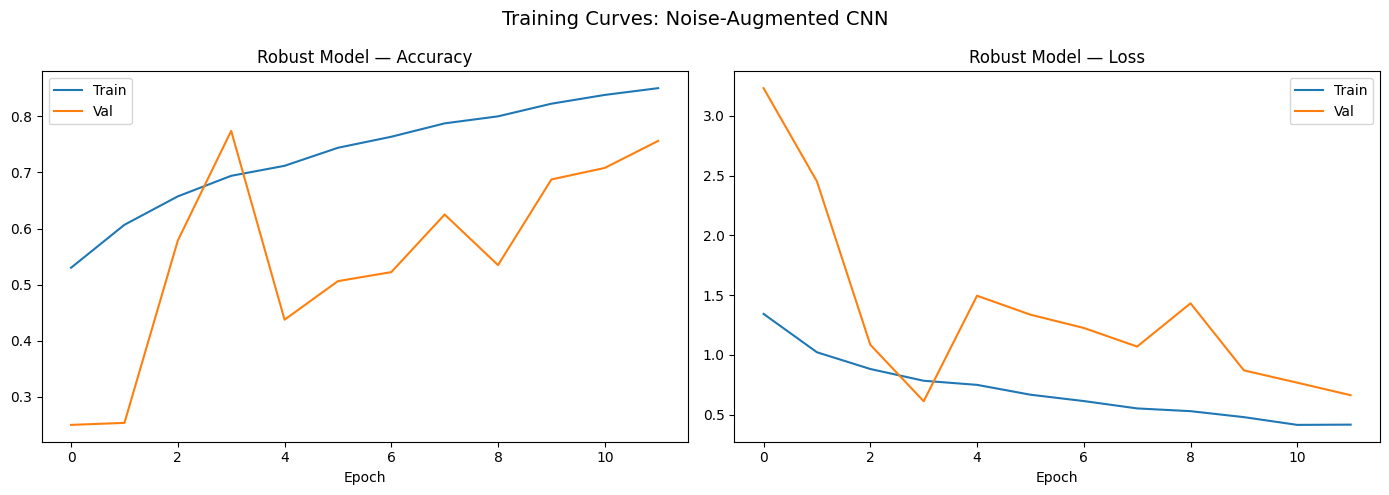

In [44]:
# Second CNN model, trained to work against noise

# Start with mild degradation, increase severity over epochs
def random_degradation_curriculum(images, epoch, total_epochs=30):
    """Scale degradation severity with training progress."""
    progress = min(epoch / (total_epochs * 0.7), 1.0)  # ramp over first 70% of training
    images = np.array(images, dtype=np.float32)
    choice = np.random.randint(0, 4)
    if choice == 0:
        std = np.random.uniform(0.02, 0.02 + 0.13 * progress)
        out = add_gaussian_noise_deg(images, std=std)
    elif choice == 1:
        amount = np.random.uniform(0.01, 0.01 + 0.07 * progress)
        out = add_salt_and_pepper(images, amount=amount)
    elif choice == 2:
        factor = np.random.uniform(0.7 - 0.5 * progress, 0.8)
        out = reduce_contrast(images, factor=factor)
    else:
        std = np.random.uniform(0.05, 0.05 + 0.15 * progress)
        out = add_speckle_noise(images, std=std)
    return out.astype(np.float32)


def random_degradation(images):
    """Apply a random degradation to a batch of images (numpy)."""
    images = np.array(images, dtype=np.float32)
    choice = np.random.randint(0, 4)
    if choice == 0:
        out = add_gaussian_noise_deg(images, std=np.random.uniform(0.02, 0.15))
    elif choice == 1:
        out = add_salt_and_pepper(images, amount=np.random.uniform(0.01, 0.08))
    elif choice == 2:
        out = reduce_contrast(images, factor=np.random.uniform(0.2, 0.7))
    else:
        out = add_speckle_noise(images, std=np.random.uniform(0.05, 0.20))
    return out.astype(np.float32)

def noise_augment_map(x, y):
    def _apply_noise(images):
        return tf.numpy_function(random_degradation, [images], tf.float32)

    degraded = _apply_noise(x)
    degraded.set_shape(x.shape)
    
    # 70% chance of degraded, 30% clean
    use_noise = tf.random.uniform(()) > 0.30
    out = tf.cond(use_noise, lambda: degraded, lambda: x)
    return out, y

# Build a fresh model for noise-augmented training
robust_model = build_cnn(IMG_SIZE, NUM_CLASSES)
robust_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create noise-augmented training pipeline
train_ds_noisy = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_noisy = (
    train_ds_noisy
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
    .map(noise_augment_map, num_parallel_calls=tf.data.AUTOTUNE)      # ← degradation first
    .map(lambda x, y: (data_augmentation(x, training=True), y),       # ← geometric aug second
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# During robust model training, track BOTH clean and noisy val accuracy
X_val_noisy = add_gaussian_noise_deg(X_val, std=0.10)
val_ds_noisy = tf.data.Dataset.from_tensor_slices((X_val_noisy, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Use a custom callback to log both
class DualValCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        _, noisy_acc = self.model.evaluate(val_ds_noisy, verbose=0)
        print(f"  val_noisy_acc: {noisy_acc:.4f}")

robust_callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,   # ← increased from 5
                                   monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5,              # ← increased from 3
                                       monitor='val_loss'),
    DualValCallback()
]

print("Training noise-augmented (robust) model...")
robust_history = robust_model.fit(
    train_ds_noisy,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=robust_callbacks
)

# Plot training curves for robust model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(robust_history.history['accuracy'], label='Train')
ax1.plot(robust_history.history['val_accuracy'], label='Val')
ax1.set_title('Robust Model — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(robust_history.history['loss'], label='Train')
ax2.plot(robust_history.history['val_loss'], label='Val')
ax2.set_title('Robust Model — Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('Training Curves: Noise-Augmented CNN', fontsize=14)
plt.tight_layout()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step
ROBUST MODEL — Clean Test Set
Accuracy: 0.7044

              precision    recall  f1-score   support

      glioma       0.77      0.54      0.63       400
  meningioma       0.72      0.36      0.48       400
     notumor       0.70      0.95      0.81       400
   pituitary       0.67      0.97      0.79       400

    accuracy                           0.70      1600
   macro avg       0.71      0.70      0.68      1600
weighted avg       0.71      0.70      0.68      1600



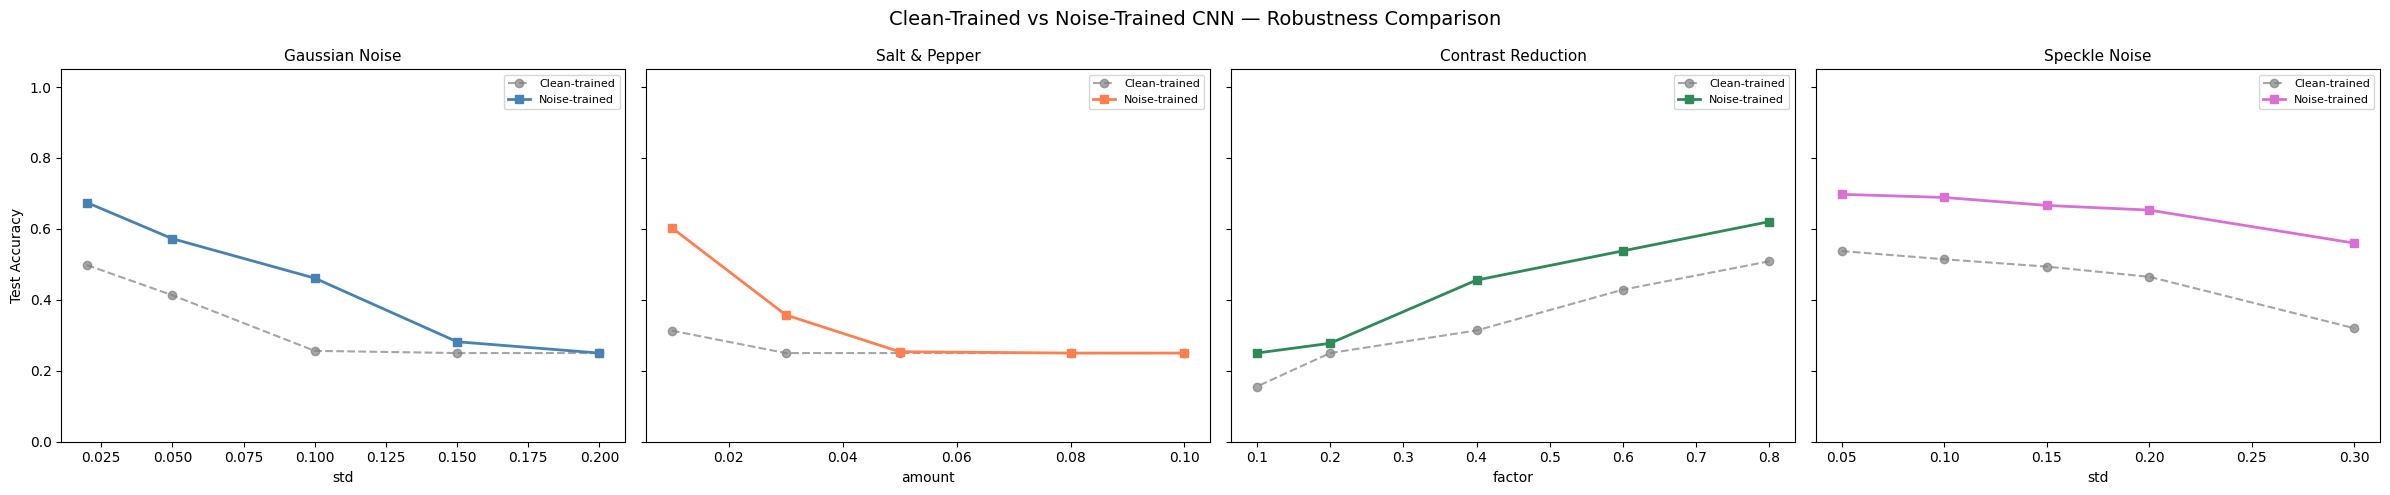

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step


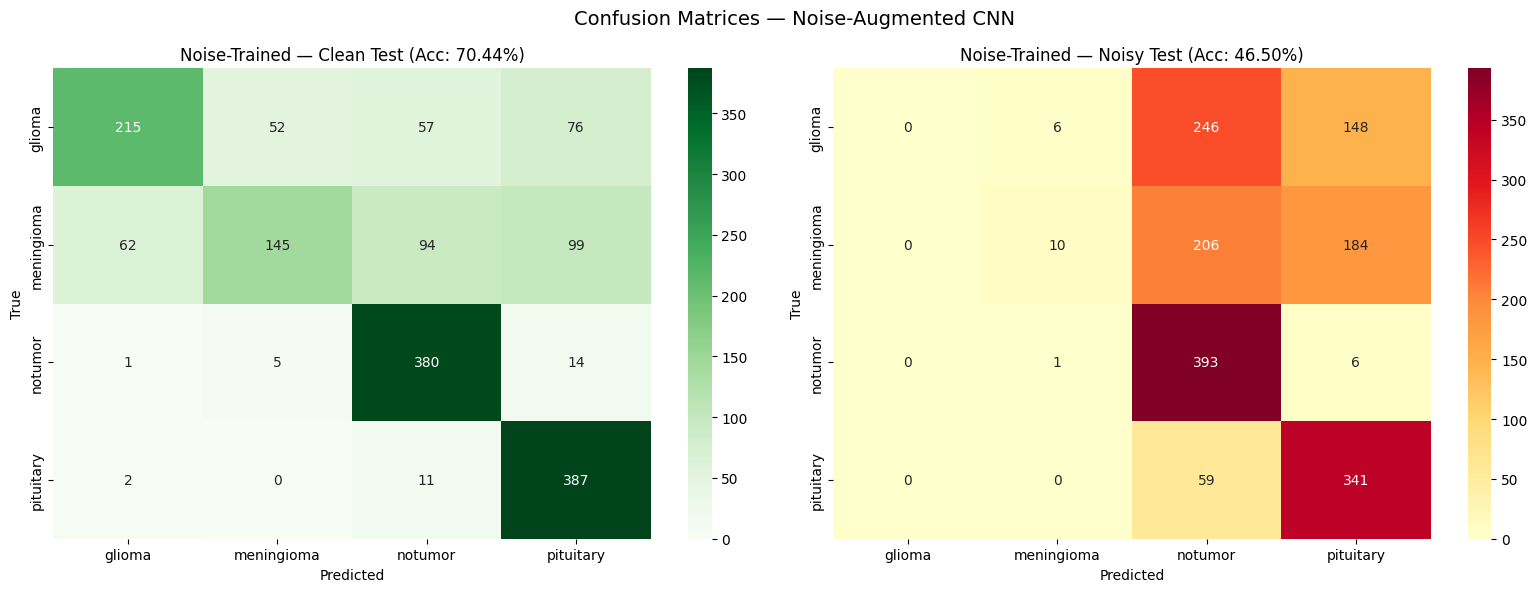


FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED MODEL
       Degradation  Intensity  Clean-Trained Acc  Noise-Trained Acc  Improvement
    Gaussian Noise     0.0200             0.4981             0.6744       0.1762
    Gaussian Noise     0.0500             0.4131             0.5725       0.1594
    Gaussian Noise     0.1000             0.2562             0.4612       0.2050
    Gaussian Noise     0.1500             0.2500             0.2819       0.0319
    Gaussian Noise     0.2000             0.2500             0.2500       0.0000
     Salt & Pepper     0.0100             0.3131             0.6031       0.2900
     Salt & Pepper     0.0300             0.2500             0.3575       0.1075
     Salt & Pepper     0.0500             0.2500             0.2537       0.0037
     Salt & Pepper     0.0800             0.2500             0.2500       0.0000
     Salt & Pepper     0.1000             0.2500             0.2500       0.0000
Contrast Reduction     0.8000             0.5088     

In [45]:
# Copmaring models

# --- Evaluate robust model on clean test data ---
y_robust_pred = np.argmax(robust_model.predict(X_test), axis=1)
robust_clean_acc = accuracy_score(y_test, y_robust_pred)

print("=" * 77)
print("ROBUST MODEL — Clean Test Set")
print("=" * 77)
print(f"Accuracy: {robust_clean_acc:.4f}\n")
print(classification_report(y_test, y_robust_pred, target_names=CLASS_NAMES))

# --- Sweep robust model across all degradation types ---
robust_results = {}
for deg_name, (deg_fn, param_name, values) in DEGRADATIONS.items():
    accs = []
    for val in values:
        X_degraded = deg_fn(X_test, **{param_name: val})
        y_deg_pred = np.argmax(robust_model.predict(X_degraded, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_deg_pred)
        accs.append(acc)
    robust_results[deg_name] = (values, accs)

# --- Side-by-side comparison plots ---
fig, axes = plt.subplots(1, len(DEGRADATIONS), figsize=(24, 5), sharey=True)
for ax, deg_name, color in zip(axes, DEGRADATIONS.keys(), colors):
    vals = results[deg_name][0]
    ax.plot(vals, results[deg_name][1], 'o--', color='gray', linewidth=1.5,
            label='Clean-trained', alpha=0.7)
    ax.plot(vals, robust_results[deg_name][1], 's-', color=color, linewidth=2,
            label='Noise-trained')
    ax.set_title(deg_name, fontsize=11)
    ax.set_xlabel(DEGRADATIONS[deg_name][1])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Test Accuracy')
plt.suptitle('Clean-Trained vs Noise-Trained CNN — Robustness Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# --- Confusion matrices for robust model: clean vs worst degradation ---
y_robust_noisy_pred = np.argmax(robust_model.predict(X_test_noisy), axis=1)
robust_noisy_acc = accuracy_score(y_test, y_robust_noisy_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_robust_clean = confusion_matrix(y_test, y_robust_pred)
sns.heatmap(cm_robust_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Noise-Trained — Clean Test (Acc: {robust_clean_acc:.2%})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_robust_noisy = confusion_matrix(y_test, y_robust_noisy_pred)
sns.heatmap(cm_robust_noisy, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Noise-Trained — Noisy Test (Acc: {robust_noisy_acc:.2%})')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrices — Noise-Augmented CNN', fontsize=14)
plt.tight_layout()
plt.show()

# --- Final summary table ---
print("\n" + "=" * 77)
print("FINAL COMPARISON: CLEAN-TRAINED vs NOISE-TRAINED MODEL")
print("=" * 77)
summary_data = []
for deg_name in DEGRADATIONS:
    vals = results[deg_name][0]
    for i, val in enumerate(vals):
        summary_data.append({
            'Degradation': deg_name,
            'Intensity': val,
            'Clean-Trained Acc': results[deg_name][1][i],
            'Noise-Trained Acc': robust_results[deg_name][1][i],
            'Improvement': robust_results[deg_name][1][i] - results[deg_name][1][i]
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False, float_format='%.4f'))

# Overall averages
avg_clean_model = df_summary['Clean-Trained Acc'].mean()
avg_robust_model = df_summary['Noise-Trained Acc'].mean()
print(f"\nAvg accuracy across all degradations:")
print(f"  Clean-trained model:  {avg_clean_model:.4f}")
print(f"  Noise-trained model:  {avg_robust_model:.4f}")
print(f"  Average improvement:  {avg_robust_model - avg_clean_model:+.4f}")